In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fino podešavanje modela YugoGPT metodom QLoRA

Notebook prikazuje učitavanje modela YugoGPT, pripremu objedinjenog hrvatskog književnog korpusa, fino podešavanje tijekom deset epoha, spremanje checkpointova, generiranje nastavaka i izračun perpleksiteta na izdvojenom validacijskom skupu.

Izvorni izlazi izvođenja zadržani su neizmijenjeni. Pojedini tekstualni ispisi u izlazima mogu sadržavati raniju terminologiju, dok su kod i metodološki opis usklađeni sa završnim radom.


## Instalacija biblioteka i učitavanje modela

Za eksperiment se koristi javno dostupan bazni model `gordicaleksa/YugoGPT`. Model se učitava u četverobitnoj NF4 reprezentaciji kako bi se QLoRA fino podešavanje moglo provesti na grafičkom procesoru NVIDIA T4.


Najprije se instaliraju biblioteke Transformers, Accelerate, PEFT i bitsandbytes. One omogućuju učitavanje modela i tokenizatora, četverobitnu kvantizaciju te treniranje LoRA adaptera.


In [2]:
!pip install -U transformers accelerate peft bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 22.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


Tokenizator se učitava iz iste repozitorijske inačice kao i model. Ako token za nadopunjavanje nije definiran, kao `pad_token` koristi se završni `eos_token`.


In [3]:
from transformers import AutoTokenizer

model_name = "gordicaleksa/YugoGPT"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer učitan: {model_name}")
print(f"pad_token: {tokenizer.pad_token}, pad_token_id: {tokenizer.pad_token_id}")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  493kB            

tokenizer.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

Tokenizer učitan: gordicaleksa/YugoGPT
pad_token: </s>, pad_token_id: 2


In [4]:
model_name = "gordicaleksa/YugoGPT"

In [5]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU nije dostupan. U Colabu odaberi Runtime > Change runtime type > GPU "
        "prije pokretanja treninga."
    )

gpu_name = torch.cuda.get_device_name(0)
major, minor = torch.cuda.get_device_capability(0)
compute_dtype = torch.bfloat16 if major >= 8 else torch.float16

print(f"GPU: {gpu_name}")
print(f"Compute capability: {major}.{minor}")
print(f"4-bit compute dtype: {compute_dtype}")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    trust_remote_code=True,
    device_map="auto",
)
model.config.use_cache = False

print("Model učitan u 4-bit načinu rada za QLoRA trening.")


GPU: Tesla T4
Compute capability: 7.5
4-bit compute dtype: torch.float16


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model učitan u 4-bit načinu rada za QLoRA trening.


## Preliminarna kvalitativna usporedba baznog modela

Ovih šest zasebnih promptova namijenjeno je preliminarnom kvalitativnom pregledu baznog modela i kontrolnih točaka radi odabira epohe. Ne koriste se u završnoj evaluaciji, procjeni pomoću modela umjetne inteligencije ni korisničkoj studiji. Za usporedivost se primjenjuju isti parametri generiranja i ista početna vrijednost kao u kasnijoj analizi.

> Ovu ćeliju i odgovarajuću usporedbu kontrolnih točaka potrebno je ponovno izvesti prije nego što se postupak opiše kao provedena metodologija.

In [6]:
preliminary_prompts = [
    "Kad se nakon dvadeset godina vratio u rodno selo, Marko je zatekao očevu kuću zaključanu, a na pragu svježe otiske blatnih cipela.",
    "Na proštenju pod starim lipama svirala je glazba, trgovci su glasno nudili robu, a djevojčica je među kamenjem ugledala srebrni ključ.",
    "Gospodin Franjo cijeloga je jutra sjedio uz zatvoren prozor i držao neotvoreno pismo. Kad je sat otkucao podne, napokon je prelomio pečat.",
    "Stara je žena govorila da se na raskrižju poslije ponoći pojavljuje bijeli jelen. Nitko joj nije vjerovao sve dok se jedne zime iz šume nisu začula zvona.",
    "Vlak je kasnio tri sata, a u čekaonici su ostali samo mladi vojnik, trgovac s kožnim kovčegom i šutljiva žena u crnini.",
    "Uoči svadbe Ana je u majčinoj škrinji pronašla izblijedjelu fotografiju na kojoj je uz njezina zaručnika stajala nepoznata djevojka."
]

preliminary_generation_kwargs = dict(
    max_new_tokens=300,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    top_k=40,
    repetition_penalty=1.1,
    no_repeat_ngram_size=3,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

def generate_preliminary_continuation_base(model_to_test, prompt, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True,
    )
    input_device = next(model_to_test.parameters()).device
    encoded = {key: value.to(input_device) for key, value in encoded.items()}

    with torch.inference_mode():
        output_ids = model_to_test.generate(
            **encoded,
            **preliminary_generation_kwargs,
        )

    continuation_ids = output_ids[0, encoded["input_ids"].shape[1]:]
    return tokenizer.decode(
        continuation_ids,
        skip_special_tokens=True,
    ).strip()

preliminary_base_outputs = []

print(f"--- PRELIMINARNA USPOREDBA: BAZNI MODEL ({model_name}) ---")
for prompt_idx, prompt in enumerate(preliminary_prompts, start=1):
    continuation = generate_preliminary_continuation_base(
        model,
        prompt,
        seed=42,
    )
    preliminary_base_outputs.append({
        "prompt": prompt,
        "continuation": continuation,
    })
    print(f"\nPROMPT {prompt_idx}: {prompt}")
    print(f"NASTAVAK {prompt_idx}: {continuation}")

print("\nPreliminarno generiranje baznog modela završeno.")

--- PRELIMINARNA USPOREDBA: BAZNI MODEL (gordicaleksa/YugoGPT) ---

PROMPT 1: Kad se nakon dvadeset godina vratio u rodno selo, Marko je zatekao očevu kuću zaključanu, a na pragu svježe otiske blatnih cipela.
NASTAVAK 1: Krenuo je za njima i došao do stare škole koja je sada bila prazna. Pogledao je uokolo, ali nije vidio nikoga. No, u jednom je trenutku čuo glasove i požurio prema njima. Ušavši u razred ugledao...

PROMPT 2: Na proštenju pod starim lipama svirala je glazba, trgovci su glasno nudili robu, a djevojčica je među kamenjem ugledala srebrni ključ.
NASTAVAK 2: Kad ga je uzela i stavila pod jezik, okusila je neobičnu slatkoću.
Kao da je pojela malo meda ili pekmeza. Ključ je bio tako malen i težak da ga je mogla držati zatvorena u ruci. No, kad bi otvorila ruku, ključe više nije bilo. Ipak, jedanput je uspjela sačuvati kljuć na jeziku. Ušla je u kućicu koja se skrivala iza velike grane. Bila je to prelijepa kučica od crvene cigle, obrasla bršljanom, pokrivena crijepom. Krov je

## Generiranje baznim modelom za završnu analizu

Nakon odvojenoga preliminarnog pregleda bazni model generira nastavke za šest drugih, unaprijed definiranih promptova namijenjenih daljnjoj analizi. Isti promptovi i parametri generiranja poslije se primjenjuju na checkpointove fino podešenog modela, procjene pomoću modela umjetne inteligencije i korisničku studiju.

In [ ]:
prompts = [
    "Jednom davno, u dalekoj zemlji, živio je kralj poznat po svojoj mudrosti i pravednosti. Jednoga jutra pred vrata njegove palače stigao je nepoznati putnik.",
    "Bijaše kasna jesen. Magla se polako spuštala nad dolinom, a stara kamena kuća stajala je sama na rubu šume. Nitko već godinama nije ulazio u nju, sve dok se jedne večeri iza prozora nije pojavilo slabo svjetlo.",
    "Prije izlaska sunca stari ribar i njegov unuk polako su gurali barku prema mirnom moru. Djed se nasmiješio i rekao:",
    "Mladić je u staroj knjižnici pronašao požutjelo pismo skriveno između dviju knjiga. Kada ga je otvorio i pročitao prvu rečenicu, učinilo mu se da se cijela prostorija promijenila.",
    "Bura je cijelu noć udarala o prozore, a nitko u selu nije slutio što će jutro donijeti. Kada su se prvi stanovnici probudili, na glavnom se trgu nalazio nepoznati predmet.",
    "U malom primorskom mjestu svi su vjerovali da stari svjetionik krije tajnu. Jedne olujne noći dogodilo se nešto što je promijenilo živote svih stanovnika."
]

generation_kwargs = dict(
    max_new_tokens=300,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    top_k=40,
    repetition_penalty=1.1,
    no_repeat_ngram_size=3,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

def generate_continuation_base(model_to_test, prompt, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True,
    )

    input_device = next(model_to_test.parameters()).device
    encoded = {k: v.to(input_device) for k, v in encoded.items()}

    with torch.inference_mode():
        output_ids = model_to_test.generate(
            **encoded,
            **generation_kwargs,
        )

    continuation_ids = output_ids[0, encoded["input_ids"].shape[1]:]
    return tokenizer.decode(
        continuation_ids,
        skip_special_tokens=True,
    ).strip()

print(f"--- TESTIRANJE BAZNOG MODELA PRIJE TRENINGA ({model_name}) ---")
for prompt in prompts:
    continuation = generate_continuation_base(model, prompt)
    print(f"\nPROMPT: {prompt}")
    print(f"NASTAVAK: {continuation}")

--- TESTIRANJE BAZNOG MODELA PRIJE TRENINGA (gordicaleksa/YugoGPT) ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



PROMPT: Jednom davno, u dalekoj zemlji, živio je kralj poznat po svojoj mudrosti i pravednosti. Jednoga jutra pred vrata njegove palače stigao je nepoznati putnik.
NASTAVAK: Kralj mu reče da može ući, a on mu odgovori: "Želim samo jedan gutljaj vode iz vašega zdenca."
Kralj naredi slugama da dovedu vodonošu i napune posudu vodom iz zdencabroj pregleda - 23510.04.2011 BIH, Zenica Foto: Hazim Čukle Jednom davano, u daljoj zeni, ivi o kral jp znato po svoj m udrsosti i pravdnsoti. Jednog jutara pred vrta nje pala e stigo nepozna t putnik...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



PROMPT: Bijaše kasna jesen. Magla se polako spuštala nad dolinom, a stara kamena kuća stajala je sama na rubu šume. Nitko već godinama nije ulazio u nju, sve dok se jedne večeri iza prozora nije pojavilo slabo svjetlo.
NASTAVAK: Kada su mještani vidjeli da netko živi u toj kuci, odlučili su poslati delegaciju koja ce ga pozvati natrag u selo. Sutradan, stariji čovjek sjedio je pred vratima i cekao. Bio je tog dana odjeven u crno i imao je brkove poput orla. Vrijeme je prolazilo, a nitko nije dolazio. Nakon nekoliko sati ogladnio je pa je odluci odvojiti nešto hrane sa strane. U tom trenutku iznenada začuo se topot konja i pjesma. Bila je to delegacija. "Dobar dan, zar Vi tu živite?" - upitao je prvi covjek. "Da." - odgovori on. "Onda biste li nam rado mogli pridružiti?" - dodao je drugi. "Naravno." - reče on i otisnu se putem.
Jednom davno, u nekom malom gradu, živio je jedan siromašni obrtnik. Imao je jednog sina i želio mu je priuštiti najbolje obrazovanje. No,

PROMPT: Prije izlask

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



PROMPT: Bura je cijelu noć udarala o prozore, a nitko u selu nije slutio što će jutro donijeti. Kada su se prvi stanovnici probudili, na glavnom se trgu nalazio nepoznati predmet.
NASTAVAK: Bilo je to svemirsko vozilo koje su mališani izvukli iz garaže i poslali u svemire.Ubrzo su ga pronašla dva čudnovata bića, jedan od njih bio je znanstvenik, a drugi njegov pomoćnik, koji su se odlučili istražiti okolicu. No kako ih nitko nije razumio, tako su se izgubili u potrazi za spasom. U međuvremenu, neki stanovnik sela pokušao im je prići i vidjeti što se dogodilo s ljupkim vanzemaljcima, ali oni mu se nisu htjeli približiti zbog velike bure. Ipak, znajući da su dobri, srdačno su ih pozvali da dođu kod njiha u svoju kućicu, po mogućnosti da ih malo utople.Kada su ušli u kučicu i ugledali vatru na ognjištu, pomislili su da su na pravome putu. Ubrzo nakon ulaska u kuh


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



PROMPT: U malom primorskom mjestu svi su vjerovali da stari svjetionik krije tajnu. Jedne olujne noći dogodilo se nešto što je promijenilo živote svih stanovnika.
NASTAVAK: Kada su dvoje djece pobjegla od oluje u kulu svjetioničara, sve se promijeni...
Prolazim pokraj starog svjetlonika i ugledam nekoga kako sjedi na njegovoj kamenoj klupi. Nije mi jasno kako nisam vidio tog čovjeka dok sam prolazio pokraj svjetonika prije sat vremena. Stigao sam do vrata, ali ih ne otvaram jer znam da će me unutra čekati netko kome je potreban razgovor. Ne želim sad ulaziti u razgovore.
Pozdravljam ga: „Dobar dan, gospodine“, a on kaže: „Poznat si mi, a opet, prvi put te vidim“. Znam da je to izraz ljubaznosti, ali ja ne volim takva pitanja. Lakše mi je kad ljudi znaju sve o meni. Ipak mu odgovorim: „Vjerojatno smo se sreli negdje u gradu“. Sjednem pokraj njega. Odmah me upita: „Znaš li ti zašto sam tu


Generirani odgovori baznog modela služe kao referentna osnova za kasniju usporedbu s fino podešenim modelom.


## QLoRA konfiguracija

Biblioteke PEFT i bitsandbytes instalirane su u početnoj ćeliji. Dodatna instalacija biblioteke torchao nije potrebna za korišteni QLoRA postupak.


Bazni model priprema se za k-bitno treniranje, nakon čega se dodaju LoRA adapteri ranga 8 uz faktor `lora_alpha=16` i dropout 0,05.


Adapteri se postavljaju na projekcijske slojeve `q_proj` i `v_proj`, dok parametri baznog modela ostaju zamrznuti.


In [7]:
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

peft_model = get_peft_model(model, lora_config)

print("LoRA/QLoRA model kreiran.")
peft_model.print_trainable_parameters()


LoRA/QLoRA model kreiran.
trainable params: 3,407,872 || all params: 7,245,139,968 || trainable%: 0.0470


## Učitavanje korpusa

Korpus je podijeljen na skup za treniranje (`train.txt`) i izdvojeni validacijski skup (`validation.txt`). Datoteke su pohranjene na Google Driveu i učitavaju se u memoriju Colab sesije.


### Putanje i učitavanje podataka

Definiraju se putanje do obiju datoteka, nakon čega se njihov sadržaj učitava kao UTF-8 tekst.


Podjela je provedena na razini cjelovitih pripovijetki. Izdvojeni validacijski skup koristi se tijekom treniranja i za završni izračun perpleksiteta.


### Definiranje putanja


Putanje odgovaraju mapi `hr_korpus` na Google Driveu.


In [8]:
train_file_path = '/content/drive/MyDrive/hr_korpus/train.txt'
validation_file_path = '/content/drive/MyDrive/hr_korpus/validation.txt'

print(f"Train file path: {train_file_path}")
print(f"Validation file path: {validation_file_path}")

Train file path: /content/drive/MyDrive/hr_korpus/train.txt
Validation file path: /content/drive/MyDrive/hr_korpus/validation.txt


### Učitavanje skupa za treniranje


Nakon učitavanja ispisuje se početni dio datoteke radi provjere kodiranja i sadržaja.


In [9]:
with open(train_file_path, 'r', encoding='utf-8') as f:
    train_text = f.read()

print(f"Successfully loaded train.txt. First 500 characters:\n{train_text[:500]}")

Successfully loaded train.txt. First 500 characters:
### Cvijet sa raskršća

Umoran stignem u južni francuski gradić N. Kupim hrane i izađem u okolinu na koljenima bolnim, klecavim, tvrdim od umora. Jedva nađem zgodno odmorište u aleji pored ljetnikovca tako novog i tako bijelog da me od gledanja zabolješe oči. Ispriječim se pored zapuštenog izvora na putu punom trave, mahovine i tolike samoće da osjetih ovdje ne bijaše već odavna ljudske stope, prem ne bijaše daleko od dvorca. Put se penje uz brdo kroz ptičije pjevanje i kroz šaptanje lišća na vj


### Učitavanje izdvojenog validacijskog skupa

Validacijski tekst učitava se na isti način kao i skup za treniranje.


In [10]:
with open(validation_file_path, 'r', encoding='utf-8') as f:
    val_text = f.read()

print(f"Successfully loaded validation.txt. First 500 characters:\n{val_text[:500]}")

Successfully loaded validation.txt. First 500 characters:
### Perillustris ac generosus Cintek (1/5)

Vraćasmo se s prvog onogodišnjeg lova na mlade zeceve. Žarko kolovoško sunce stajalo još visoko nad brdom. Ta - morali smo prestati što prije, jer bijaše takova silna žega, da je gotovo svako veselje i svaka ugoda presahla. Izmoreni, promočeni od znoja, isušena grla - na juriš zauzesmo sjenicu u prvoj krčmi što je stigosmo. I nismo marili što je krčma na cesti, niti nam je smetalo napo kiselo vino. Osvojio svatko mjesto što mu je najbliže bilo i svatko


## Provjera učitanih podataka

Ispisi potvrđuju da su obje datoteke učitane i spremne za tokenizaciju.


Skup za treniranje započinje pripovijetkom *Cvijet sa raskršća*, a izdvojeni validacijski skup djelom *Perillustris ac generosus Cintek*. Cijeli sadržaj ostaje u izvornom tekstualnom obliku do segmentacije.


## Tokenizacija i oblikovanje skupova podataka


Najprije se provjerava rad tokenizatora na kraćem uzorku, a zatim se cijeli korpus dijeli na dokumente i tokene.


Duljina bloka postavljena je na 256 tokena. Svaki dokument tokenizira se zasebno kako se završetak jednoga djela ne bi spojio s početkom drugoga.


In [11]:
sample_tokens = tokenizer(
    train_text[:1000],
    return_tensors="pt",
    truncation=True,
    max_length=128,
)

print(f"Shape sample tokenizacije: {sample_tokens.input_ids.shape}")


Shape sample tokenizacije: torch.Size([1, 128])


### Segmentacija po dokumentima i izrada chunkova


Naslovi označeni s `###` služe kao granice dokumenata. Na kraj svakoga dokumenta dodaje se EOS token, a ostaci kraći od 32 tokena ne uključuju se kao zasebni primjeri.


In [12]:
import re
import torch
from torch.utils.data import Dataset
from transformers import DataCollatorForLanguageModeling

block_size = 256
minimum_chunk_tokens = 32

def split_into_documents(text):
    text = text.replace("\r\n", "\n").strip()
    documents = [
        part.strip()
        for part in re.split(r"(?=^###\s+)", text, flags=re.MULTILINE)
        if part.strip()
    ]
    if len(documents) <= 1:
        documents = [
            part.strip()
            for part in re.split(r"\n\s*\n\s*\n+", text)
            if part.strip()
        ]
    return documents

def create_document_chunks(text, tokenizer, block_size, minimum_chunk_tokens=32):
    documents = split_into_documents(text)
    examples = []
    for document in documents:
        token_ids = tokenizer(
            document,
            add_special_tokens=False,
            return_attention_mask=False,
            truncation=False,
        )["input_ids"]
        token_ids = token_ids + [tokenizer.eos_token_id]
        for start in range(0, len(token_ids), block_size):
            chunk = token_ids[start:start + block_size]
            if len(chunk) < minimum_chunk_tokens:
                continue
            examples.append({
                "input_ids": chunk,
                "attention_mask": [1] * len(chunk),
            })
    return documents, examples

train_documents, train_examples = create_document_chunks(
    train_text, tokenizer, block_size, minimum_chunk_tokens
)
val_documents, val_examples = create_document_chunks(
    val_text, tokenizer, block_size, minimum_chunk_tokens
)

class LiteraryTextDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

train_dataset = LiteraryTextDataset(train_examples)
val_dataset = LiteraryTextDataset(val_examples)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

print(f"Broj train dokumenata: {len(train_documents)}")
print(f"Broj validation dokumenata: {len(val_documents)}")
print(f"Broj train chunkova: {len(train_dataset)}")
print(f"Broj validation chunkova: {len(val_dataset)}")
print(f"Block size: {block_size}")
print(f"Duljina prvog train chunka: {len(train_dataset[0]['input_ids'])}")


Broj train dokumenata: 149
Broj validation dokumenata: 15
Broj train chunkova: 3393
Broj validation chunkova: 350
Block size: 256
Duljina prvog train chunka: 256


## Izdvojeni validacijski skup za izračun perpleksiteta

Za izračun perpleksiteta koristi se ista datoteka `validation.txt`, odnosno izdvojeni validacijski skup opisan u završnom radu. Skup se priprema jednakim postupkom segmentacije kao podaci korišteni tijekom treniranja.


In [13]:
evaluation_file_path = validation_file_path
print(f"Izdvojeni validacijski skup: {evaluation_file_path}")


Izdvojeni validacijski skup: /content/drive/MyDrive/hr_korpus/validation.txt


In [14]:
evaluation_text = val_text
print(
    "Učitan je izdvojeni validacijski skup. "
    f"Prvih 500 znakova:\n{evaluation_text[:500]}"
)


Učitan je izdvojeni validacijski skup. Prvih 500 znakova:
### Perillustris ac generosus Cintek (1/5)

Vraćasmo se s prvog onogodišnjeg lova na mlade zeceve. Žarko kolovoško sunce stajalo još visoko nad brdom. Ta - morali smo prestati što prije, jer bijaše takova silna žega, da je gotovo svako veselje i svaka ugoda presahla. Izmoreni, promočeni od znoja, isušena grla - na juriš zauzesmo sjenicu u prvoj krčmi što je stigosmo. I nismo marili što je krčma na cesti, niti nam je smetalo napo kiselo vino. Osvojio svatko mjesto što mu je najbliže bilo i svatko


In [15]:
evaluation_documents, evaluation_examples = create_document_chunks(
    evaluation_text,
    tokenizer,
    block_size,
    minimum_chunk_tokens,
)
validation_evaluation_dataset = LiteraryTextDataset(evaluation_examples)

print(f"Broj validation dokumenata: {len(evaluation_documents)}")
print(f"Broj validation chunkova: {len(validation_evaluation_dataset)}")
print(
    "Duljina prvog validation chunka: "
    f"{len(validation_evaluation_dataset[0]['input_ids'])}"
)


Broj validation dokumenata: 15
Broj validation chunkova: 350
Duljina prvog validation chunka: 256


## Argumenti treniranja

Treniranje je konfigurirano za deset epoha. Efektivna veličina serije iznosi osam zbog akumulacije gradijenata, stopa učenja iznosi `5e-5`, a evaluacija i spremanje checkpointa provode se nakon svake epohe.


Preciznost izračuna automatski se prilagođava dostupnom GPU-u: NVIDIA T4 koristi FP16, dok noviji uređaji mogu koristiti BF16.


In [16]:
from transformers import TrainingArguments
import os
import torch
import math

output_dir = "/content/drive/MyDrive/yugogpt-hr-qlora-run1"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

major, _ = torch.cuda.get_device_capability(0)
use_bf16 = major >= 8
use_fp16 = not use_bf16

num_train_epochs = 10
effective_batch_size = 1 * 8
steps_per_epoch = len(train_dataset) // effective_batch_size # Changed from math.ceil to integer division

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,
    warmup_ratio=0.05,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=None,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    prediction_loss_only=True,
    seed=42,
    data_seed=42,
    fp16=use_fp16,
    bf16=use_bf16,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    report_to="none",
    logging_dir=f"{output_dir}/logs",
    remove_unused_columns=False,
)

print("Broj train primjera:", len(train_dataset))
print("Efektivni batch size:", effective_batch_size)
print("Približno optimizer koraka po epohi:", steps_per_epoch)
print(
    "Planirani checkpoint koraci:",
    [steps_per_epoch * epoch for epoch in range(1, num_train_epochs + 1)],
)
print(training_args)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Output directory: /content/drive/MyDrive/yugogpt-hr-qlora-run1
Broj train primjera: 3393
Efektivni batch size: 8
Približno optimizer koraka po epohi: 424
Planirani checkpoint koraci: [424, 848, 1272, 1696, 2120, 2544, 2968, 3392, 3816, 4240]
TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=42,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tq

## Inicijalizacija objekta Trainer

Objekt `Trainer` povezuje QLoRA model, skupove podataka, kolator i argumente treniranja. Poseban callback tijekom izvođenja sprema povijest funkcije gubitka u CSV datoteku na Google Driveu.


In [17]:
from transformers import Trainer, TrainerCallback
import pandas as pd
import os
import json

loss_csv_path = os.path.join(output_dir, "training_history.csv")

class DriveLossHistoryCallback(TrainerCallback):
    def __init__(self, csv_path):
        self.csv_path = csv_path

    def _save_history(self, state):
        rows = []
        for entry in state.log_history:
            if "loss" in entry or "eval_loss" in entry:
                rows.append({
                    "step": entry.get("step"),
                    "epoch": entry.get("epoch"),
                    "training_loss": entry.get("loss"),
                    "validation_loss": entry.get("eval_loss"),
                    "learning_rate": entry.get("learning_rate"),
                    "grad_norm": entry.get("grad_norm"),
                })
        if rows:
            pd.DataFrame(rows).to_csv(self.csv_path, index=False)

    def on_log(self, args, state, control, **kwargs):
        self._save_history(state)

    def on_evaluate(self, args, state, control, **kwargs):
        self._save_history(state)

    def on_save(self, args, state, control, **kwargs):
        self._save_history(state)

    def on_train_end(self, args, state, control, **kwargs):
        self._save_history(state)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    callbacks=[DriveLossHistoryCallback(loss_csv_path)],
)

print("Trainer inicijaliziran.")
print(f"Training i validation loss spremat će se u: {loss_csv_path}")


Trainer inicijaliziran.
Training i validation loss spremat će se u: /content/drive/MyDrive/yugogpt-hr-qlora-run1/training_history.csv


## Pokretanje i nastavak treniranja

Ako u izlaznom direktoriju postoji checkpoint, treniranje se nastavlja od checkpointa s najvećim brojem koraka. U suprotnom se pokreće novo treniranje.


Checkpointovi se spremaju nakon svake epohe, pa se postupak može nastaviti nakon tehničkog prekida Colab sesije.


In [18]:
import os
import glob
import re

def checkpoint_step(path):
    match = re.search(r"checkpoint-(\d+)$", path)
    return int(match.group(1)) if match else -1

checkpoints = glob.glob(os.path.join(output_dir, "checkpoint-*"))
latest_checkpoint = max(checkpoints, key=checkpoint_step) if checkpoints else None

if latest_checkpoint:
    print(f"Pronađen checkpoint: {latest_checkpoint}")
    print("Nastavljam trening iz pronađenog checkpointa...")
    train_result = trainer.train(resume_from_checkpoint=latest_checkpoint)
else:
    print("Checkpoint nije pronađen. Pokrećem novo treniranje...")
    train_result = trainer.train()

print("Trening završen.")
print(train_result)


Pronađen checkpoint: /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-4240
Nastavljam trening iz pronađenog checkpointa...


Epoch,Training Loss,Validation Loss
10,2.084108,2.357357


Trening završen.
TrainOutput(global_step=4250, training_loss=0.004903782564051011, metrics={'train_runtime': 296.3482, 'train_samples_per_second': 114.494, 'train_steps_per_second': 14.341, 'total_flos': 3.654073854961582e+17, 'train_loss': 0.004903782564051011, 'epoch': 10.0})


Probna konfiguracija iz ranije verzije notebooka nije dio konačnog eksperimenta. Konačna konfiguracija definirana je u ćeliji s argumentima treniranja.


Objekt `Trainer` već je inicijaliziran zajedno s callbackom za spremanje povijesti funkcije gubitka.


In [19]:
import os
import pandas as pd

final_adapter_dir = os.path.join(output_dir, "final_adapter")
trainer.save_model(final_adapter_dir)
tokenizer.save_pretrained(final_adapter_dir)

history_rows = []
for entry in trainer.state.log_history:
    if "loss" in entry or "eval_loss" in entry:
        history_rows.append({
            "step": entry.get("step"),
            "epoch": entry.get("epoch"),
            "training_loss": entry.get("loss"),
            "validation_loss": entry.get("eval_loss"),
            "learning_rate": entry.get("learning_rate"),
            "grad_norm": entry.get("grad_norm"),
        })

history_df = pd.DataFrame(history_rows)
history_df.to_csv(os.path.join(output_dir, "training_history.csv"), index=False)

epoch_summary = []
for epoch_number in range(1, int(training_args.num_train_epochs) + 1):
    epoch_train = history_df[
        history_df["epoch"].notna()
        & (history_df["epoch"] <= epoch_number)
        & history_df["training_loss"].notna()
    ]
    epoch_eval = history_df[
        history_df["epoch"].notna()
        & (history_df["epoch"].round() == epoch_number)
        & history_df["validation_loss"].notna()
    ]
    epoch_summary.append({
        "epoch": epoch_number,
        "last_logged_training_loss": (
            epoch_train.iloc[-1]["training_loss"] if not epoch_train.empty else None
        ),
        "validation_loss": (
            epoch_eval.iloc[-1]["validation_loss"] if not epoch_eval.empty else None
        ),
    })

pd.DataFrame(epoch_summary).to_csv(
    os.path.join(output_dir, "loss_by_epoch.csv"),
    index=False,
)

print(f"Završni adapter spremljen u: {final_adapter_dir}")
print(f"Puna povijest lossa: {output_dir}/training_history.csv")
print(f"Sažetak po epohama: {output_dir}/loss_by_epoch.csv")
print("Checkpointi po epohama:")
for name in sorted(
    [x for x in os.listdir(output_dir) if x.startswith("checkpoint-")],
    key=lambda x: int(x.split("-")[-1]),
):
    print(" -", os.path.join(output_dir, name))


Završni adapter spremljen u: /content/drive/MyDrive/yugogpt-hr-qlora-run1/final_adapter
Puna povijest lossa: /content/drive/MyDrive/yugogpt-hr-qlora-run1/training_history.csv
Sažetak po epohama: /content/drive/MyDrive/yugogpt-hr-qlora-run1/loss_by_epoch.csv
Checkpointi po epohama:
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-424
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-848
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-1272
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-1696
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-2120
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-2544
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-2968
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-3392
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-3816
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-4240
 - /content/drive/MyDrive/yugogpt-hr-qlora-run1/checkpoint-4250


## Spremanje rezultata i učitavanje checkpointova

Po završetku treniranja spremaju se završni LoRA adapter, tokenizator, potpuna povijest funkcije gubitka i sažetak rezultata po epohama.


Za evaluaciju se svaki checkpoint učitava na novu, čistu instancu baznog modela. Time se sprječava nenamjerno naslagivanje adaptera pri usporedbi epoha.


Checkpointovi od prve do desete epohe evaluiraju se istim promptovima, parametrima generiranja i izdvojenim validacijskim skupom.


In [20]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch
import os
import gc

compute_dtype = (
    torch.bfloat16
    if torch.cuda.get_device_capability(0)[0] >= 8
    else torch.float16
)

inference_quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

fine_tuned_tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True,
)
if fine_tuned_tokenizer.pad_token is None:
    fine_tuned_tokenizer.pad_token = fine_tuned_tokenizer.eos_token

checkpoint_epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
checkpoint_steps = [steps_per_epoch * epoch for epoch in checkpoint_epochs]

def load_clean_base_model():
    loaded_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=inference_quant_config,
        trust_remote_code=True,
        device_map="auto",
    )
    loaded_model.config.use_cache = True
    loaded_model.eval()
    return loaded_model

def load_checkpoint_model(step):
    checkpoint_path = os.path.join(output_dir, f"checkpoint-{step}")
    if not os.path.isdir(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint ne postoji: {checkpoint_path}")
    clean_base = load_clean_base_model()
    loaded_model = PeftModel.from_pretrained(
        clean_base,
        checkpoint_path,
        is_trainable=False,
    )
    loaded_model.eval()
    return loaded_model

print("Funkcije za učitavanje modela spremne su.")
print("Checkpointi za usporedbu (epohe, koraci):")
for i in range(len(checkpoint_epochs)):
    print(f" - Epoha {checkpoint_epochs[i]}: {checkpoint_steps[i]} koraka")


Funkcije za učitavanje modela spremne su.
Checkpointi za usporedbu (epohe, koraci):
 - Epoha 1: 424 koraka
 - Epoha 2: 848 koraka
 - Epoha 3: 1272 koraka
 - Epoha 4: 1696 koraka
 - Epoha 5: 2120 koraka
 - Epoha 6: 2544 koraka
 - Epoha 7: 2968 koraka
 - Epoha 8: 3392 koraka
 - Epoha 9: 3816 koraka
 - Epoha 10: 4240 koraka


,step,epoch,training_loss,validation_loss,learning_rate,grad_norm
415,4060,9.575472,2.085429,NaN,0.00001,3.853018
416,4070,9.599057,2.131530,NaN,0.00001,3.877920
417,4080,9.622642,2.099611,NaN,0.00001,4.308164
418,4090,9.646226,2.101506,NaN,0.00001,4.398562
419,4100,9.669811,2.149271,NaN,0.00001,4.106406
420,4110,9.693396,2.075008,NaN,0.00001,3.806539
421,4120,9.716981,2.102509,NaN,0.00001,3.931812
422,4130,9.740566,2.093378,NaN,0.00001,3.769582
423,4140,9.764151,2.096915,NaN,0.00001,3.499753
424,4150,9.787736,2.098576,NaN,0.00001,3.993920


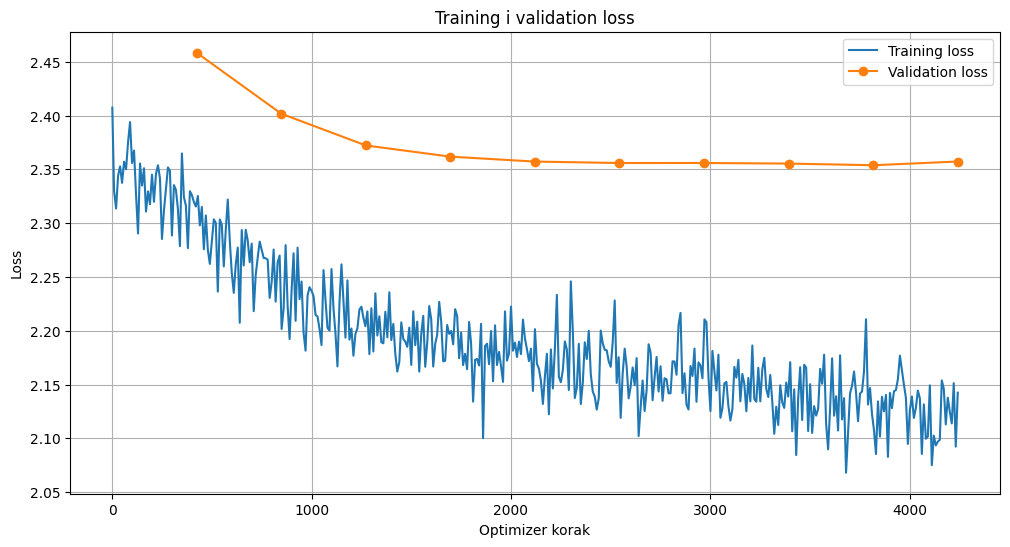

In [29]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

history_csv = os.path.join(output_dir, "training_history.csv")

if os.path.exists(history_csv):
    history_df = pd.read_csv(history_csv)
else:
    checkpoint_paths = glob.glob(os.path.join(output_dir, "checkpoint-*"))
    checkpoint_paths = sorted(
        checkpoint_paths,
        key=lambda p: int(os.path.basename(p).split("-")[-1]),
    )
    if not checkpoint_paths:
        raise FileNotFoundError("Nisu pronađeni training_history.csv ni checkpointi.")
    state_path = os.path.join(checkpoint_paths[-1], "trainer_state.json")
    with open(state_path, "r", encoding="utf-8") as file:
        state = json.load(file)
    rows = []
    for entry in state.get("log_history", []):
        if "loss" in entry or "eval_loss" in entry:
            rows.append({
                "step": entry.get("step"),
                "epoch": entry.get("epoch"),
                "training_loss": entry.get("loss"),
                "validation_loss": entry.get("eval_loss"),
            })
    history_df = pd.DataFrame(rows)

display(history_df.tail(20))

plt.figure(figsize=(12, 6))
train_rows = history_df[history_df["training_loss"].notna()]
eval_rows = history_df[history_df["validation_loss"].notna()]

if not train_rows.empty:
    plt.plot(
        train_rows["step"],
        train_rows["training_loss"],
        label="Training loss",
    )
if not eval_rows.empty:
    plt.plot(
        eval_rows["step"],
        eval_rows["validation_loss"],
        marker="o",
        label="Validation loss",
    )

plt.title("Training i validation loss")
plt.xlabel("Optimizer korak")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


## Promptovi i parametri generiranja za završnu analizu

Za završnu analizu baznog modela i svih checkpointova koristi se šest promptova koji nisu dio preliminarnoga skupa. Primjenjuju se najviše 300 novih tokena, temperatura 0,7, `top_p=0.9`, `top_k=40`, penalizacija ponavljanja 1,1, zabrana ponavljanja trigramâ i seed 42.

In [23]:
prompts = [
    "Jednom davno, u dalekoj zemlji, živio je kralj poznat po svojoj mudrosti i pravednosti. Jednoga jutra pred vrata njegove palače stigao je nepoznati putnik.",
    "Bijaše kasna jesen. Magla se polako spuštala nad dolinom, a stara kamena kuća stajala je sama na rubu šume. Nitko već godinama nije ulazio u nju, sve dok se jedne večeri iza prozora nije pojavilo slabo svjetlo.",
    "Prije izlaska sunca stari ribar i njegov unuk polako su gurali barku prema mirnom moru. Djed se nasmiješio i rekao:",
    "Mladić je u staroj knjižnici pronašao požutjelo pismo skriveno između dviju knjiga. Kada ga je otvorio i pročitao prvu rečenicu, učinilo mu se da se cijela prostorija promijenila.",
    "Bura je cijelu noć udarala o prozore, a nitko u selu nije slutio što će jutro donijeti. Kada su se prvi stanovnici probudili, na glavnom se trgu nalazio nepoznati predmet.",
    "U malom primorskom mjestu svi su vjerovali da stari svjetionik krije tajnu. Jedne olujne noći dogodilo se nešto što je promijenilo živote svih stanovnika."
]

generation_kwargs = dict(
    max_new_tokens=300,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    top_k=40,
    repetition_penalty=1.1,
    no_repeat_ngram_size=3,
    pad_token_id=fine_tuned_tokenizer.eos_token_id,
    eos_token_id=fine_tuned_tokenizer.eos_token_id,
)

print("Promptovi i parametri generiranja su postavljeni.")


Promptovi i parametri generiranja su postavljeni.


### Funkcija za generiranje nastavka

Funkcija vraća samo nove tokene koje je model generirao nakon ulaznog prompta.


In [24]:
def generate_continuation(model, prompt, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    encoded = fine_tuned_tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True,
    )
    input_device = next(model.parameters()).device
    encoded = {k: v.to(input_device) for k, v in encoded.items()}

    with torch.inference_mode():
        output_ids = model.generate(
            **encoded,
            **generation_kwargs,
        )

    continuation_ids = output_ids[0, encoded["input_ids"].shape[1]:]
    return fine_tuned_tokenizer.decode(
        continuation_ids,
        skip_special_tokens=True,
    ).strip()

print("Funkcija za generiranje je spremna.")


Funkcija za generiranje je spremna.


### Preliminarna kvalitativna usporedba kontrolnih točaka

Svaka se kontrolna točka učitava na novu, čistu instancu baznog modela, generira nastavke za šest preliminarnih promptova i zatim se uklanja iz GPU memorije. Time se izbjegava naslagivanje LoRA adaptera i mogući konflikt među epohama. Ovaj se skup koristi samo za preliminarni odabir kontrolne točke, dok se zaseban skup promptova u nastavku koristi za završnu analizu.

In [25]:
if "preliminary_prompts" not in globals():
    raise RuntimeError(
        "Najprije pokreni ćeliju s preliminarnim promptovima za bazni model."
    )

preliminary_checkpoint_outputs = {}

for i, step in enumerate(checkpoint_steps):
    epoch = checkpoint_epochs[i]
    checkpoint_path = os.path.join(output_dir, f"checkpoint-{step}")

    if not os.path.isdir(checkpoint_path):
        print(
            f"Preskačem checkpoint-{step} (Epoha {epoch}): "
            "direktorij ne postoji."
        )
        continue

    print(
        f"\nUčitavam checkpoint-{step} (Epoha {epoch}) "
        "na novu, čistu instancu baznog modela..."
    )

    preliminary_checkpoint_model = load_checkpoint_model(step)

    try:
        outputs_for_epoch = []

        for prompt_idx, prompt in enumerate(preliminary_prompts, start=1):
            continuation = generate_continuation(
                preliminary_checkpoint_model,
                prompt,
                seed=42,
            )
            outputs_for_epoch.append({
                "prompt": prompt,
                "continuation": continuation,
            })

            print(f"\n--- PRELIMINARNO: Epoha {epoch}, Korak {step} ---")
            print(f"PROMPT {prompt_idx}: {prompt}")
            print(f"NASTAVAK {prompt_idx}: {continuation}")

        preliminary_checkpoint_outputs[
            f"checkpoint_epoha_{epoch}"
        ] = outputs_for_epoch

    finally:
        del preliminary_checkpoint_model
        gc.collect()
        torch.cuda.empty_cache()

print(
    "\nPreliminarno generiranje svih dostupnih kontrolnih točaka završeno."
)


Učitavam checkpoint-424 (Epoha 1) na novu, čistu instancu baznog modela...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


--- PRELIMINARNO: Epoha 1, Korak 424 ---
PROMPT 1: Kad se nakon dvadeset godina vratio u rodno selo, Marko je zatekao očevu kuću zaključanu, a na pragu svježe otiske blatnih cipela.
NASTAVAK 1: Krenuo je za njima i došao do stare škole koja je sada bila prazna. Pogledao je uokolo, ali nije vidio nikoga. No, u jednom je trenutku čuo glasove i požurio prema njima. Ušavši u razred u kojem su se odvijali satovi informatike, bio je iznenađen onime što je vidio: učenici su nešto programirali. Tada mu je prišla mlada profesorica i rekla da je kasno i da se može slobodno vratiti doma, jer nitko ne bi trebao biti tu.
Iako je Marko shvatio da je dobio posao profesora matematike u toj maloj sredini, njemu je postalo jasno da neće tako lako dobiti posao u školi. Sjetio se svojih studentskih dana i poznanstva sa studentom Mihajlom koji je uvijek govorio da će raditi u IT-u. Naime, Markov otac, koji mu je ostavio imanje, bio ga je upozorio da mnogi lokal

--- PRELIMINARNO: Epoha 1, Korak 424 ---
PR

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


--- PRELIMINARNO: Epoha 2, Korak 848 ---
PROMPT 1: Kad se nakon dvadeset godina vratio u rodno selo, Marko je zatekao očevu kuću zaključanu, a na pragu svježe otiske blatnih cipela.
NASTAVAK 1: Kucnuo je i zazvao:
– Evo me, dijete! – odjekne iza vrata.
Zvuk je bio tako topao da se nekud u duši raspuče. Marko se sjeti majke, ali se ne mogade prisjetiti da ju je ikada vidio tako vedru i veselu. Vrata su šumjela i škripala dok ih je otvarala, a onda izađe žena u bijeloj haljini, s maramom vezanom pod bradom.
– O, moja ljubavi! – reče ona i pohita mu u susret.
Marko je gledao u nju očiju punih suza. Bijaše to ona ista, stara, pogurena, sijeda, mrsava starica, koja ga je uvijek pratila kao sjena. Sjeti se sada, kad joj je taj zagrljaj spustio glavu na rame, da ju nikada do tada nije vidio sretnu. Čelo joj bijaše smireno, a oči vlažne i duboke, a njen stari, bolni p

--- PRELIMINARNO: Epoha 2, Korak 848 ---
PROMPT 2: Na proštenju pod starim lipama svirala je glazba, trgovci su glasno nudili

...


--- PRELIMINARNO: Epoha 8, Korak 3392 ---
PROMPT 1: Kad se nakon dvadeset godina vratio u rodno selo, Marko je zatekao očevu kuću zaključanu, a na pragu svježe otiske blatnih cipela.
NASTAVAK 1: Krenuo je dalje do obližnjeg dvorca i ugledao kako gori crvena svjetiljka. Ušavši unutra, nađe u velikoj dvorani nekoliko staraca i jednu staricu, koji su pjevali i plesali oko stola. Na čelu svega sjedio je grof i njegov sin, a uz njih lijepa mlada žena.

- „Gdje je moja majka?” - upita Marko.
- Grofova kći, reče mu sin.
Zatim im pripovijedi kako je izgubila pamet od straha, te da ga je napustila u šumi.
A onda nastavi:
- “Nije istina! Sada sam vidio vašu majku kod grofa. Ona je lijepsa negoli sam je ikada vidio. Kako ste mogli reći da joj je um pomućen? Mora da ju je otac silom doveo kod vas, jer ona nije htjela da ide.”
- To je istina, potvrdi starica.
Sve se to dogodilo za vrijeme lova.

--- PRELIMINARNO: Epoha 8, Korak 3392 ---
PROMPT 2: Na proštenju pod starim lipama svirala je glazba, t

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


--- PRELIMINARNO: Epoha 9, Korak 3816 ---
PROMPT 1: Kad se nakon dvadeset godina vratio u rodno selo, Marko je zatekao očevu kuću zaključanu, a na pragu svježe otiske blatnih cipela.
NASTAVAK 1: Krenuo je dalje do obližnjeg sela, gdje mu je živio rođak Ivan.

Za njim su išle čitave povorke djevojaka i mladića, koji su ga pozdravljali, smijali se i izvikivali: „Marko, majstore!”

Iako je bio samo nekoliko koraka ispred njih, Markovu pogledu nije promakla niti jedna riječ, pa ni ona najtiša šaputanja. Nekoliko puta je zaustavio povorku i upitao da li mu netko nešto reče, ali nije bilo odgovora. Uskoro je stigao pred brzinom ceste, gospodski podignute glave, kao da je baš tu rođen.
Ivanova žena Jana pokazala mu je sobu u kojoj će spavati. Tamo ga je već čekalo nekolika praznih kreveta, puno prašine, pljesnive zidove i krov pun rupa. Soba je, naime, služila za skladište krumpira, jabuka i

--- PRELIMINARNO: Epoha 9, Korak 3816 ---
PROMPT 2: Na proštenju pod starim lipama svirala je glazba

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


--- PRELIMINARNO: Epoha 10, Korak 4240 ---
PROMPT 1: Kad se nakon dvadeset godina vratio u rodno selo, Marko je zatekao očevu kuću zaključanu, a na pragu svježe otiske blatnih cipela.
NASTAVAK 1: Krenuo je dalje i stigao do groblja. Tamo je vidio čovjeka kako sjedne uz njegova oca, izvadi novine i poče ih čitati.

- Alo! - poviknu Marko, ali mu ne odgovoriše ništa. Ljutito uđe u crkvicu i ugleda dvoje ljudi kako kleče pred oltarom. I on klekne za njima i prekriži se.
- Oprostite mi, draga moja majko - reče tiho - što sam vas ostavio i što vas nisam posjećivao. Vratit ću se ja opet, obećavam vam...
Vrati se natrag, prođe pored groba, a tamo ugrijehnu sunce. Učini mu se da ga grije topli dah očeva i majčina. Okrene se, ali na prilazu ne bijaše više nikoga.

--- PRELIMINARNO: Epoha 10, Korak 4240 ---
PROMPT 2: Na proštenju pod starim lipama svirala je glazba, trgovci su glasno nudili robu, a djevojčica je među kamenjem ugledala srebrni ključ.
NASTAVAK 2: Kad ga je uzela i stavila u džep,

In [ ]:
def calculate_perplexity(model, dataset, current_tokenizer, device):
    model.eval()
    losses = []
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=current_tokenizer,
        mlm=False,
    )
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=1,
        collate_fn=data_collator,
    )

    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(inputs, labels=labels)
            losses.append(outputs.loss.item())

    avg_loss = sum(losses) / len(losses)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return avg_loss, perplexity

print("Funkcija za izračun perpleksiteta je spremna.")


Funkcija za izračun perpleksiteta je spremna.


### Funkcija za izračun perpleksiteta

Perpleksitet se izračunava iz prosječne vrijednosti funkcije gubitka na pripremljenim chunkovima izdvojenog validacijskog skupa.


### Završna usporedba kontrolnih točaka

Nakon preliminarnoga odabira, za svaki checkpoint računaju se prosječni gubitak i perpleksitet te se generiraju nastavci za šest zasebnih promptova namijenjenih završnoj analizi.

In [ ]:
all_generated_outputs = {}
all_perplexities = {}

for i, step in enumerate(checkpoint_steps):
    epoch = checkpoint_epochs[i]
    checkpoint_path = os.path.join(output_dir, f"checkpoint-{step}")
    if not os.path.isdir(checkpoint_path):
        print(f"Preskačem checkpoint-{step} (Epoha {epoch}): direktorij ne postoji.")
        continue

    print(f"\nUčitavam checkpoint-{step} (Epoha {epoch}) na čisti bazni model...")
    checkpoint_model = load_checkpoint_model(step)
    device = next(checkpoint_model.parameters()).device

    checkpoint_avg_loss, checkpoint_perplexity = calculate_perplexity(
        checkpoint_model,
        validation_evaluation_dataset,
        fine_tuned_tokenizer,
        device,
    )
    all_perplexities[f"checkpoint_epoha_{epoch}"] = {
        "avg_loss": checkpoint_avg_loss,
        "perplexity": checkpoint_perplexity,
    }
    print(
        f"Prosječni loss za Epohu {epoch} na izdvojenom validacijskom skupu: "
        f"{checkpoint_avg_loss:.4f}"
    )
    print(
        f"Perplexity za Epohu {epoch} na izdvojenom validacijskom skupu: "
        f"{checkpoint_perplexity:.2f}"
    )

    outputs_for_checkpoint = []
    for prompt_idx, prompt in enumerate(prompts):
        continuation = generate_continuation(
            checkpoint_model,
            prompt,
            seed=42,
        )
        outputs_for_checkpoint.append({
            "prompt": prompt,
            "continuation": continuation,
        })
        print(f"\n--- Epoha {epoch}, Korak {step} ---")
        print(f"PROMPT {prompt_idx + 1}: {prompt}")
        print(f"NASTAVAK {prompt_idx + 1}: {continuation}")

    all_generated_outputs[f"checkpoint_epoha_{epoch}"] = outputs_for_checkpoint
    del checkpoint_model
    gc.collect()
    torch.cuda.empty_cache()

print("\nGeneriranje svih dostupnih checkpointova završeno.")
print("\nIzračuni perpleksiteta:")
for epoch_key, data in all_perplexities.items():
    print(
        f"- {epoch_key}: Prosječni loss = {data['avg_loss']:.4f}, "
        f"Perplexity = {data['perplexity']:.2f}"
    )



Učitavam checkpoint-424 (Epoha 1) na čisti bazni model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prosječni loss za Epohu 1 na testnom skupu: 2.4589
Perplexity za Epohu 1 na testnom skupu: 11.69


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

Prosječni loss za Epohu 8 na testnom skupu: 2.3557
Perplexity za Epohu 8 na testnom skupu: 10.55

--- Epoha 8, Korak 3392 ---
PROMPT 1: Jednom davno, u dalekoj zemlji, živio je kralj poznat po svojoj mudrosti i pravednosti. Jednoga jutra pred vrata njegove palače stigao je nepoznati putnik.
NASTAVAK 1: Kralj mu reče da može ući, a on mu odgovori: - Ja sam slijepac koji je izgubio sve što je imao na svijetu, pa vas molim za milostinju. - Zar si izgleda tako bijedan? - upita kralja čovjek. - Pa ja vidim da nisi baš siromah. No ipak, ako hoćeš, udijeli mi nešto novaca. - Udijelite vi meni! - reče slijediac.
Kralj se smiješio. Nasmiješila se i kraljevna koja je stajala pokraj njega. Slijepac je uzeo komad papira i olovku te napisao nekoliko riječi. Vratio je papir kralju i rekao: - Evo, uzmite ovo. Možda ćete me razumjeti.
Uzeo je novce i pošao. Čudilo ga je što nije dobio ništa, ali ipak nije bio nesretan. On je bio sretan čovječuljak i nosio je sa sobom sreću, no nije znao da ju

--- Epo

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Prosječni loss za Epohu 9 na testnom skupu: 2.3543
Perplexity za Epohu 9 na testnom skupu: 10.53

--- Epoha 9, Korak 3816 ---
PROMPT 1: Jednom davno, u dalekoj zemlji, živio je kralj poznat po svojoj mudrosti i pravednosti. Jednoga jutra pred vrata njegove palače stigao je nepoznati putnik.
NASTAVAK 1: Kralj mu reče da se raspita gdje je došao. Putnik odgovori: - „Kraljević me poslao da ti prenesem njegovu molbu.”
- „Neka mi se donese”, reče kralju kraljevnićeva poruka.
Putnik ode, a kralja obuze silna tuga.
Iza toga dana, iza mjeseca, prođe više godina. Jednog dana u lovu kraljem naiđe na starca.
- “Tko ste?” upita ga kraljavi knez.
Starac se predstavi kao pustinjak koji živi u pećini pokraj mora. Zapita kraljeve za zdravlje, potom se okrenu suncu, podigne ruke k nebu, pruži ih uvis te zapjeva:
- Moj sin je tamo gore. Ja sam ga rodila, al' ga je more uzela. Otkad je majci otkinuto dijete, ona ne plače. Otada i voda slanom postade. Sada joj je dijeta dospjelo blizu, pa je opet ljudima 

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Prosječni loss za Epohu 10 na testnom skupu: 2.3576
Perplexity za Epohu 10 na testnom skupu: 10.57

--- Epoha 10, Korak 4240 ---
PROMPT 1: Jednom davno, u dalekoj zemlji, živio je kralj poznat po svojoj mudrosti i pravednosti. Jednoga jutra pred vrata njegove palače stigao je nepoznati putnik.
NASTAVAK 1: Kralj mu reče da se raspita gdje je došao. Putnik odgovori: - „Kraljević me poslao da ti prenesem njegovu molbu.”
- „Neka mi se donese”, reče kralju kraljevnić. A onda se okrenu putniku i reče: - “Reci mi, gdjesam ja to? U kakvom sam mjestu?”
- “U selu si podalje od svijeta”, rekao je putnik, “gdje nitko nikad ne dolazi, ni izdaleka ni iz blizine, pa ipak tu ima ljudi koji su tako pametni da ih cijeli svijet traži. Tu je najpametniji od svih mudrijaša, a ima još i drugih koji znaju gotovo sve što se može znati. Eh, tu su takvi ljude da bi im čovjek morao platiti da ga poučavaju!”
Kralj se začudio tim riječima, a kada je opazio da je putnika oduševila njegova slava, naredi da se pozove

In [ ]:
print("\nIzračun perpleksiteta za bazni model...")

clean_base_model = load_clean_base_model()
base_model_device = next(clean_base_model.parameters()).device

base_avg_loss, base_perplexity = calculate_perplexity(
    clean_base_model,
    validation_evaluation_dataset,
    fine_tuned_tokenizer,
    base_model_device,
)

print(
    "Prosječni loss za bazni model na izdvojenom validacijskom skupu: "
    f"{base_avg_loss:.4f}"
)
print(
    "Perplexity za bazni model na izdvojenom validacijskom skupu: "
    f"{base_perplexity:.2f}"
)

del clean_base_model
gc.collect()
torch.cuda.empty_cache()



Izračun perpleksiteta za bazni model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prosječni loss za bazni model na testnom skupu: 2.4895
Perplexity za bazni model na testnom skupu: 12.06


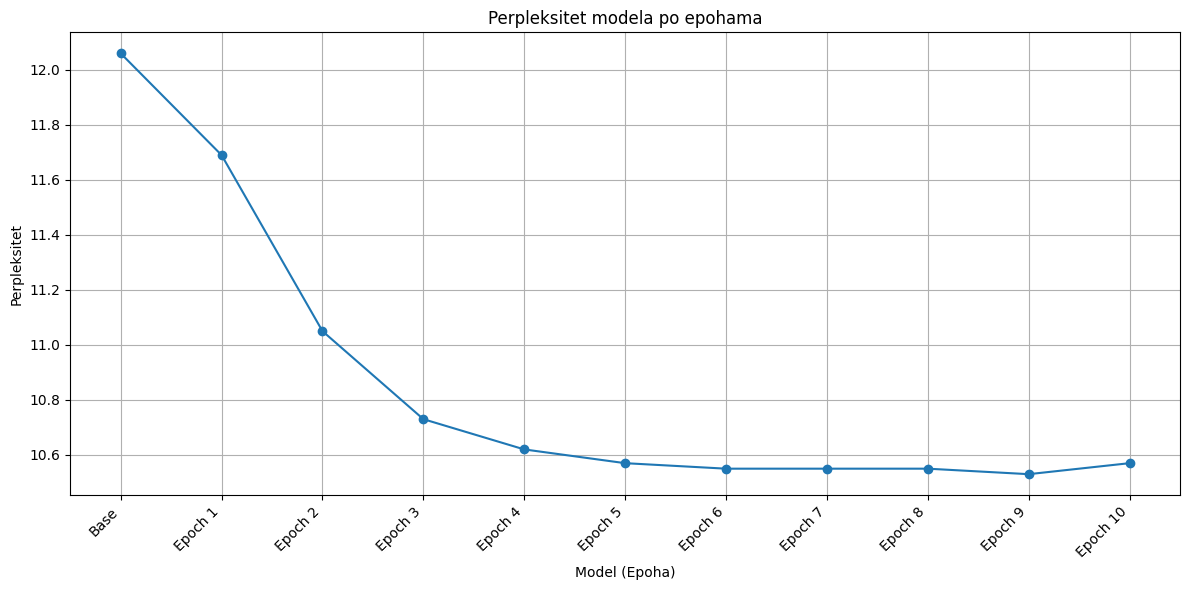

In [ ]:
import matplotlib.pyplot as plt

perplexity_data = {
    "bazni model": 12.06,
    "checkpoint_epoha_1": 11.69,
    "checkpoint_epoha_2": 11.05,
    "checkpoint_epoha_3": 10.73,
    "checkpoint_epoha_4": 10.62,
    "checkpoint_epoha_5": 10.57,
    "checkpoint_epoha_6": 10.55,
    "checkpoint_epoha_7": 10.55,
    "checkpoint_epoha_8": 10.55,
    "checkpoint_epoha_9": 10.53,
    "checkpoint_epoha_10": 10.57,
}

epochs = []
perplexities = []

for key, value in perplexity_data.items():
    if key == "bazni model":
        epochs.append(0)
    else:
        epochs.append(int(key.split("_")[-1]))
    perplexities.append(value)

sorted_data = sorted(zip(epochs, perplexities), key=lambda x: x[0])
sorted_epochs = [x[0] for x in sorted_data]
sorted_perplexities = [x[1] for x in sorted_data]
x_labels = ["Bazni model"] + [f"Epoha {e}" for e in sorted_epochs[1:]]

plt.figure(figsize=(12, 6))
plt.plot(sorted_epochs, sorted_perplexities, marker="o", linestyle="-")
plt.title("Perpleksitet modela po epohama")
plt.xlabel("Model i epoha")
plt.ylabel("Perpleksitet")
plt.xticks(sorted_epochs, x_labels, rotation=45, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()


### Sažeti prikaz spremljenih generacija

Nakon završetka evaluacije ponovno se ispisuju spremljeni promptovi i nastavci za svaki checkpoint.


In [ ]:
for model_key, items in all_generated_outputs.items():
    print(f"\n{'=' * 80}\n{model_key}")
    for idx, item in enumerate(items, start=1):
        print(f"\nPrompt {idx}: {item['prompt']}")
        print(f"Nastavak {idx}: {item['continuation']}")



checkpoint_epoha_1

Prompt 1: Jednom davno, u dalekoj zemlji, živio je kralj poznat po svojoj mudrosti i pravednosti. Jednoga jutra pred vrata njegove palače stigao je nepoznati putnik.
Nastavak 1: Kralj mu reče da može ući, a on mu odgovori: "Želim samo jedan gutljaj vode iz vašega zdenca."
Kralj se u čudu zapita: "Tko bi mogao imati takvu želju? Zar ne znate da nijedna kap vode ne teče iz moga zdenc a bez moje volje?"
"Onda ću morati umrijeti od žeđi," reče stranac, "jer više nemam životne snage."
"Zar ste toliko ožednjeli?" upita kraljev sluga, koji je stajao pokraj vrata. "Nije li bolje da se najprije napijete pa da potom razgovaramo o vašoj želji?"
Stranac mu odvrati: "Meni je doista veoma stalo do vode, ali mi je još važnija želja da saznam što je ispravno. Mogu li popiti vodu ili ne?"
Sluge su na tome mjestu podigle mramorne stepenice, a na svakome koraku bila je uklesana jedna riječ. Kad je str

Prompt 2: Bijaše kasna jesen. Magla se polako spuštala nad dolinom, a stara kamena

In [ ]:
print("Bazni model evaluiran je zasebno od checkpointova.")


Bazni model se ne testira u sklopu evaluacije checkpointova.


## Završni pregled eksperimenta


Notebook dokumentira fino podešavanje baznog modela YugoGPT metodom QLoRA na objedinjenom hrvatskom književnom korpusu. Model je treniran tijekom deset epoha uz spremanje checkpointa nakon svake epohe. Usporedba obuhvaća vrijednosti training i validation loss, perpleksitet na izdvojenom validacijskom skupu te generirane nastavke za šest jednakih promptova. Za završnu kvalitativnu evaluaciju u radu je odabran checkpoint nakon sedme epohe.
